# Week 13 — Function 01

Focused, checksum-backed review of verified evidence through Week 11. No authoritative Week 12 or Week 13 returned output is treated as an observation.

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook reviews one black-box function, presents bounded EDA, and surfaces the exact canonical Week 13 GP-UCB recommendation.

<a id="objectives"></a>
## 2. Objectives

Validate the cumulative evidence, describe the observed search history, inspect diagnostics, report the fitted GP configuration, and verify the proposed query.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

Starter observations are combined only with returned pairs in the immutable canonical ledger. Missing Week 12 and Week 13 returns are not imputed.

<a id="environment-setup"></a>
## 4. Environment and setup

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown
repo_root=Path.cwd().resolve()
while not (repo_root/'Code').exists() and repo_root!=repo_root.parent: repo_root=repo_root.parent
function_root=repo_root/'Week_13'/'Function_01'
sys.path.insert(0,str(function_root/'02_Code'))
from analyse_week_13_function_01 import analyse


<a id="data-validation"></a>
## 5. Data validation

Reconstruct the function data and validate its recorded summary before analysis.

{'week': 13,
 'function': 1,
 'dimensions': 2,
 'starter_observations': 10,
 'recorded_pairs': 11,
 'total_verified_observations': 21,
 'best_query': 3,
 'best_input': [0.7310236309563586, 0.7329998764152272],
 'best_output': 7.710875114502849e-16,
 'latest_verified_query': 21,
 'latest_verified_input': [0.353293, 0.956697],
 'latest_verified_output': 8.159220183163013e-130,
 'latest_improves_previous_best': False,
 'minimum_output': -0.0036060626443634764,
 'mean_output': -0.00017171726877917643,
 'standard_deviation': 0.0007679429718018541,
 'evidence_gap': 'No verified Week 12 or Week 13 return is present; confirmed cumulative evidence is available through Week 11.',
 'interpretation': 'Within-function descriptive evidence; no causal or cross-function ranking claim.',
 'archive_integrity': 'Original repository Week 11 arrays remain quarantined; analysis uses independently recovered pairs from the canonical ledger.'}

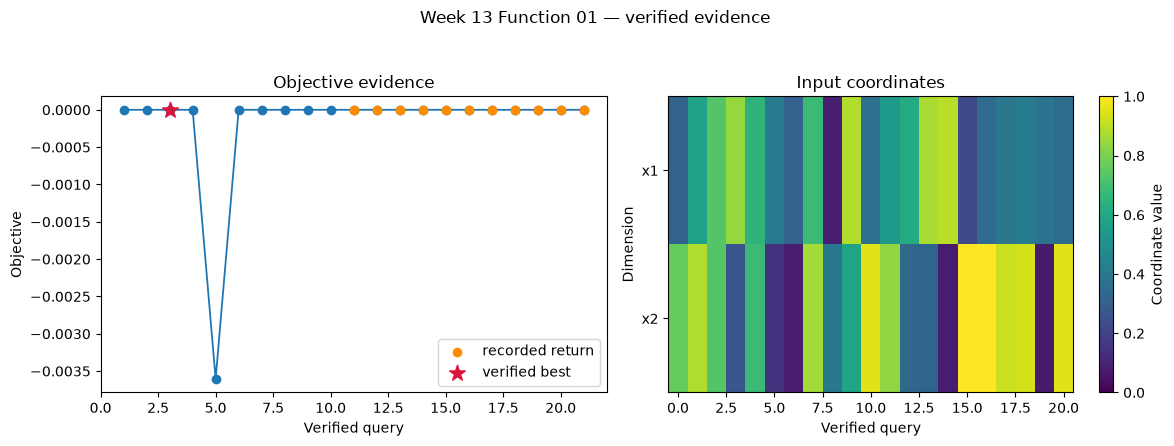

In [2]:
observations,summary,figure=analyse()
summary


<a id="descriptive-eda"></a>
## 6. Descriptive EDA

Inspect a bounded observation preview, full per-variable summary statistics, and the persisted function summary.

In [3]:
display(observations.head(10))
display(observations.describe().T)
display(pd.DataFrame([summary]))

,query,evidence,x1,x2,objective
0,1,starter,0.319404,0.762959,1.322677e-79
1,2,starter,0.574329,0.879898,1.033078e-46
2,3,starter,0.731024,0.733000,7.710875e-16
3,4,starter,0.840353,0.264732,3.341771e-124
4,5,starter,0.650114,0.681526,-3.606063e-03
5,6,starter,0.410437,0.147554,-2.159249e-54
6,7,starter,0.312691,0.078723,-2.089093e-91
7,8,starter,0.683418,0.861057,2.535001e-40
8,9,starter,0.082507,0.403488,3.606771e-81
9,10,starter,0.883890,0.582254,6.229856e-48


,count,mean,std,min,25%,50%,75%,max
query,21.0,11.000000,6.204837,1.000000,6.000000e+00,1.100000e+01,1.600000e+01,2.100000e+01
x1,21.0,0.519454,0.234471,0.082507,3.532930e-01,4.214100e-01,6.834182e-01,8.977140e-01
x2,21.0,0.609578,0.343480,0.071186,3.215980e-01,7.329999e-01,9.195310e-01,9.996730e-01
objective,21.0,-0.000172,0.000787,-0.003606,-3.089424e-96,7.651210e-239,1.322677e-79,7.710875e-16


,week,function,dimensions,starter_observations,recorded_pairs,total_verified_observations,best_query,best_input,best_output,latest_verified_query,latest_verified_input,latest_verified_output,latest_improves_previous_best,minimum_output,mean_output,standard_deviation,evidence_gap,interpretation,archive_integrity
0,13,1,2,10,11,21,3,"[0.7310236309563586, 0.7329998764152272]",7.710875e-16,21,"[0.353293, 0.956697]",8.159220e-130,False,-0.003606,-0.000172,0.000768,No verified Week 12 or Week 13 return is prese...,Within-function descriptive evidence; no causa...,Original repository Week 11 arrays remain quar...


<a id="visual-eda"></a>
## 7. Visual EDA

Display the function-level diagnostic figure generated from verified observations.

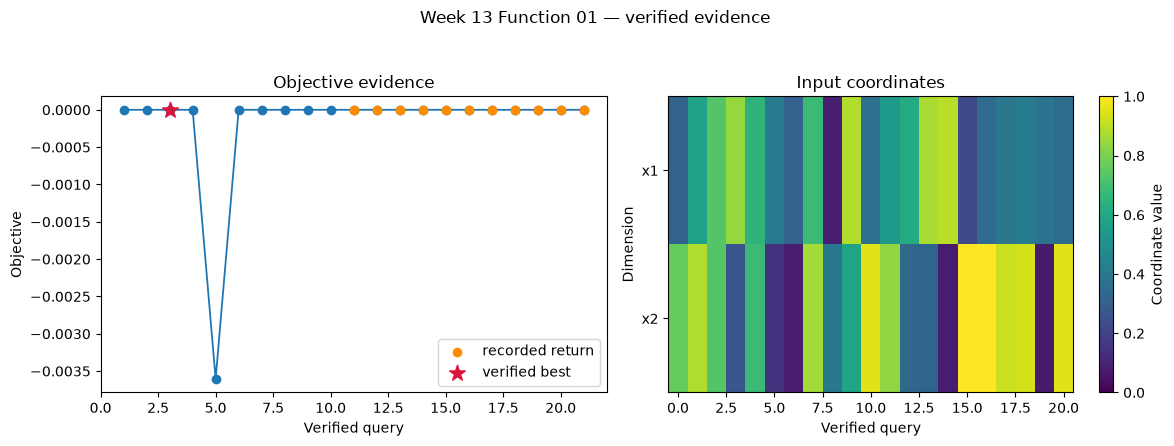

In [4]:
display(figure)

<a id="gp-model-configuration"></a>
## 8. GP model configuration

Load the canonical Week 13 GP-UCB row and expose the fitted kernel, candidate count, kappa, seed, and evidence count.

In [5]:
proposal_ledger = pd.read_csv(repo_root / 'Results' / 'week_13_gp_ucb_proposals.csv')
proposal = proposal_ledger.loc[proposal_ledger['function'].eq(1)].iloc[0]
display(proposal[['observation_count', 'kernel', 'candidate_count', 'kappa', 'random_seed']].to_frame('value'))

,value
observation_count,21
kernel,"1.22**2 * Matern(length_scale=[2, 0.0498], nu=..."
candidate_count,20000
kappa,0.1
random_seed,4201


<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Report the exact portal-formatted query, predicted mean, predictive uncertainty, and acquisition value.

In [6]:
display(proposal[['submission_query', 'predicted_mean', 'predictive_std', 'ucb_score', 'duplicate_at_6dp', 'status']].to_frame('value'))

,value
submission_query,0.997914-0.748997
predicted_mean,0.000315
predictive_std,0.000284
ucb_score,0.000344
duplicate_at_6dp,False
status,validated_proposal_only_week_12_and_13_returns...


<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

Confirm data integrity and consistency between the focused notebook and the canonical proposal ledger.

In [7]:
assert observations.shape[0]==summary['total_verified_observations']
assert observations.filter(regex=r'^x').to_numpy().min()>=0
assert observations.filter(regex=r'^x').to_numpy().max()<=1
assert observations['objective'].notna().all()
print('All Week 13 Function 01 checks passed.')
assert summary['function'] == 1
assert int(proposal['observation_count']) == observations.shape[0]
assert not bool(proposal['duplicate_at_6dp'])
assert float(proposal['kappa']) == 0.1
print('All Week 13 Function 01 workflow checks passed.')

All Week 13 Function 01 checks passed.
All Week 13 Function 01 workflow checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

Summarise the evidence-backed result without promoting a proposal to an observed return.

In [8]:
display(Markdown(f"**Verified observations:** {int(summary['total_verified_observations'])}  \n"f"**Best verified output:** {float(summary['best_output']):.8g}  \n"f"**Week 13 GP-UCB query:** `{proposal['submission_query']}`  \n"f"**UCB score:** {float(proposal['ucb_score']):.8g}  \n""Next step: append this point only after an authoritative returned output is available."))

**Verified observations:** 21  
**Best verified output:** 7.7108751e-16  
**Week 13 GP-UCB query:** `0.997914-0.748997`  
**UCB score:** 0.00034388166  
Next step: append this point only after an authoritative returned output is available.